In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
from tqdm import tqdm
import matplotlib
import pickle as pi
from funcs_for_kappa import localgap_sys


import matplotlib.pyplot as plt
import cmasher as csh
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [5]:
# model parameters
system_size = 10
A = 1.0
B = 1.0
onsite_disorder = 0
bond_power = 1.1
Delta = 2
# localizer parameters
E0 = 0.0
kappa = 1



# kappa vs E

In [6]:
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

Delta_values = np.linspace(-2, 4, 50)
W_values = np.linspace(0, 15, 50)
# localgap_grid = np.zeros((len(kappa_values), len(E_values)))

# for i, kappa in tqdm(enumerate(kappa_values)):
#     for j, E0 in enumerate(E_values):
#         localgap_grid[i, j] = localgap_sys(
#             system_size=system_size,
#             Delta=Delta,
#             A=A,
#             B=B,
#             bond_power=bond_power,
#             onsite_disorder=onsite_disorder,
#             E0=E0,
#             kappa=kappa
#         )
    
        
        

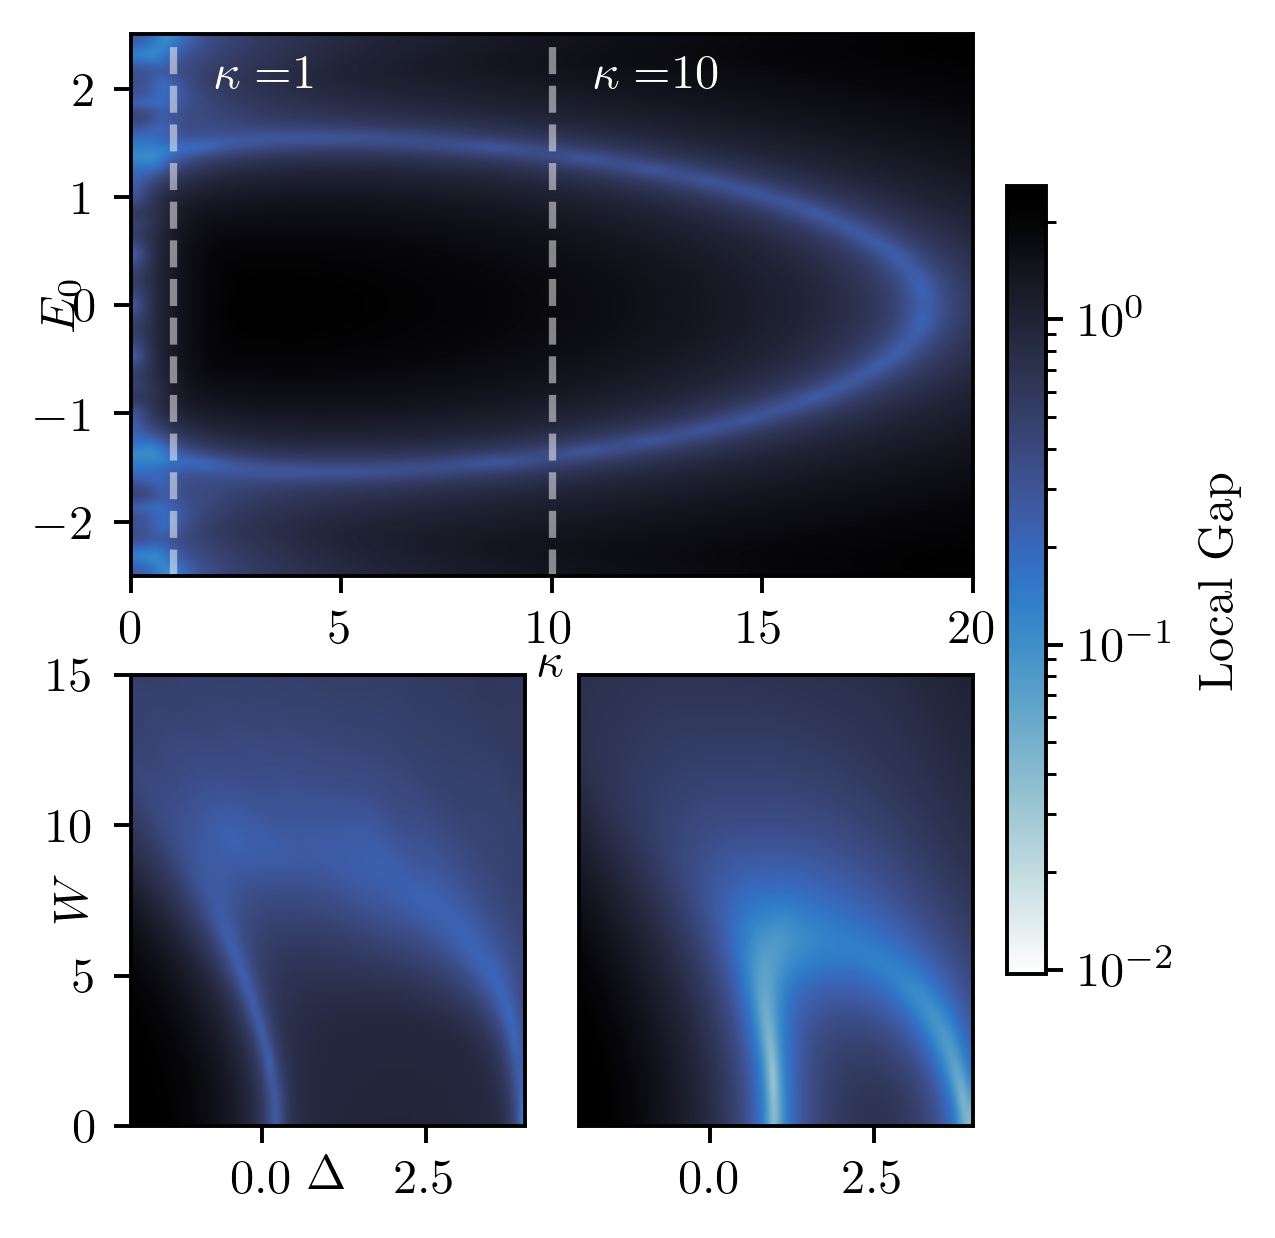

In [10]:
localgap_grid = pi.load(open("localgap_kappa_E_grid.pkl", "rb"))
avg_locgap = [
    pi.load(open("kappa-1_locgap_Delta_W_grid.pkl", "rb")),
    pi.load(open("kappa-10_locgap_Delta_W_grid.pkl", "rb"))
]

fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1, 0.05], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])
# Colorbar 
cax = fig.add_subplot(gs[:, 2])

im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log'
)


for x in [1,10]:
    ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
    ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=-2)
ax_top.set_ylabel(r'$E_0$', labelpad=-10)
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')



for i, axes in enumerate([ax_bl, ax_br]):
    im = axes.imshow(
        avg_locgap[i].T,
        extent=(Delta_values[0], Delta_values[-1], W_values[0], W_values[-1]),
        origin="lower",
        aspect="auto",
        cmap=csh.arctic_r,
        interpolation='bicubic',
        norm='log'
    )


ax_bl.set_xlabel(r'$\Delta$', labelpad=-10)
ax_bl.set_ylabel(r'$W$', labelpad=-10)
ax_br.set_yticks([])


plt.colorbar(im, ax=cax, label='Local Gap', fraction=2.0, pad=-10)
cax.set_frame_on(False)
cax.set_xticks([])
cax.set_yticks([])

plt.savefig("localgap_kappa_grid.pdf", bbox_inches='tight', dpi=350)
label = ['a)', 'b)', 'c)']
# for axes in [ax_top, ax_bl, ax_br]:
#     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)